This script tests the correspondance between annual maximum rainfall event in one grid cell and subsequent changes to the soil moisture in that grid cell

#### Load packages, set home directory

In [21]:
def mask_to_catchment(cube, catchment):

    catchment_proj = catchment.to_crs(epsg=27700)
    
    # Extract coordinates
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    
    # Create 2D meshgrid of coordinates
    xx, yy = np.meshgrid(x, y)
    
    # Flatten coordinates
    points = np.vstack((xx.ravel(), yy.ravel())).T
    
    # Get catchment geometry
    catchment_geom = catchment_proj.geometry.iloc[0]
    
    # Test which grid cells are inside catchment
    mask = np.array([catchment_geom.contains(Point(pt)) for pt in points])
    
    # Reshape to grid
    mask = mask.reshape(len(y), len(x))
    return mask

# Function to convert a cftime object to string
def cft_to_string(cfttime_obj):
    """
    Convert a cftime.Datetime360Day (or other CFTime) object to 'YYYY-MM-DD' string
    """
    # Handle PartialDateTime or cftime
    try:
        year = str(cfttime_obj.year)
        month = str(cfttime_obj.month).zfill(2)
        day = str(cfttime_obj.day).zfill(2)
        return f"{year}-{month}-{day}"
    except AttributeError:
        return None  # in case it's missing or invalid

In [22]:
import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_systems as cs
import iris.coord_categorisation as icc
import iris.analysis
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import glob as sir_globington_the_file_gatherer
import pandas as pd
import numpy as np
import contextily as ctx
from shapely.geometry import Point, Polygon, box, MultiPolygon
from shapely import vectorized, contains
from shapely.ops import unary_union
from shapely import intersects
import time
import cftime
import datetime
import cartopy.crs as ccrs
from scipy.ndimage import label, generate_binary_structure
import pickle

rainfalldir ='/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/'
# os.chdir(homedir)

In [23]:
yr = 1995

In [24]:
sm_dir = '/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_01/'
sm_one_yr = iris.load(sm_dir + f'r001i1p00000_{yr-1}1201-{yr}1130_mrso.nc')[0]

In [25]:
files = []

# December previous year FIRST
# files.append(f"{rainfalldir}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr-1}1201-{yr-1}1230.nc")

# Jan–Nov of target year
for m in range(1, 13):
    files.append(f"{rainfalldir}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc")

monthly_cubes = iris.cube.CubeList()

for f in files:
    cube = iris.load(f)[1]
    cube.attributes = {}
    monthly_cubes.append(cube)

cube_uk_oneyr = monthly_cubes.concatenate_cube()

/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/iris/fileformats/cf.py:1475: IrisCfNonSpanningVarWarning: Ignoring variable ensemble_member_id referenced by variable pr: Dimensions ('ensemble_member', 'string27') do not span ('time', 'projection_y_coordinate', 'projection_x_coordinate')
  warnings.warn(


In [26]:
catchments = gpd.read_file("/scratch/hydro4/users/kv25483/FutureFlood/Data/NewcastleExample/catchment_identifier/hyd_areas_GB_with_subcatchments.shp")
newcastle = catchments[catchments['HA_NUM'] == "23"]
catchment_poly = newcastle.geometry[60]

method = "center_point"  # choose "center_point" or "full_cell"

# --- Cube coordinates ---
x = cube_uk_oneyr.coord('projection_x_coordinate').points
y = cube_uk_oneyr.coord('projection_y_coordinate').points

dx = x[1] - x[0]  # assume uniform spacing
dy = y[1] - y[0]

# Create mask
mask = np.zeros((len(y), len(x)), dtype=bool)

if method == "center_point":
    # --- Center point approach ---
    for j, yy in enumerate(y):
        for i, xx in enumerate(x):
            pt = Point(xx, yy)
            # Use contains (strict) or intersects (include boundary)
            # mask[j, i] = catchment_poly.contains(pt)
            mask[j, i] = catchment_poly.intersects(pt)

elif method == "full_cell":
    # --- Full-cell intersection (any overlap) ---
    for j, yy in enumerate(y):
        for i, xx in enumerate(x):
            cell = box(xx - dx/2, yy - dy/2, xx + dx/2, yy + dy/2)
            mask[j, i] = cell.intersects(catchment_poly)

else:
    raise ValueError("Invalid method. Choose 'center_point' or 'full_cell'.")

# --- Apply mask to cube ---
cube_catchment = cube_uk_oneyr.copy()
cube_catchment.data = np.where(mask[np.newaxis, :, :], cube_catchment.data, np.nan)

In [27]:
rainfall_events =pd.read_csv("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_consistent/NorthEastEngland_Ens_01_1980-2000_full_events.csv")

# Create a datetime column, coercing invalid dates to NaT
rainfall_events['start_date'] = pd.to_datetime(
    dict(year=rainfall_events['start_year'],month=rainfall_events['start_month'],
        day=rainfall_events['start_day'], hour =rainfall_events['start_hour']), errors='coerce')

rainfall_events['stop_date'] = pd.to_datetime(
    dict(year=rainfall_events['stop_year'],month=rainfall_events['stop_month'],
        day=rainfall_events['stop_day'], hour =rainfall_events['stop_hour']), errors='coerce')

# Get events just for one year
rainfall_events_oneyr = rainfall_events[rainfall_events['start_year']==yr]
len(rainfall_events_oneyr)

5

In [28]:
december_1980_indices = (30*24)
yrs_before_this_yr = yr - 1981
yrs_before_this_yr_indices = yrs_before_this_yr * 360 * 24
correction_factor = yrs_before_this_yr_indices + december_1980_indices

/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/iris/common/mixin.py:195: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


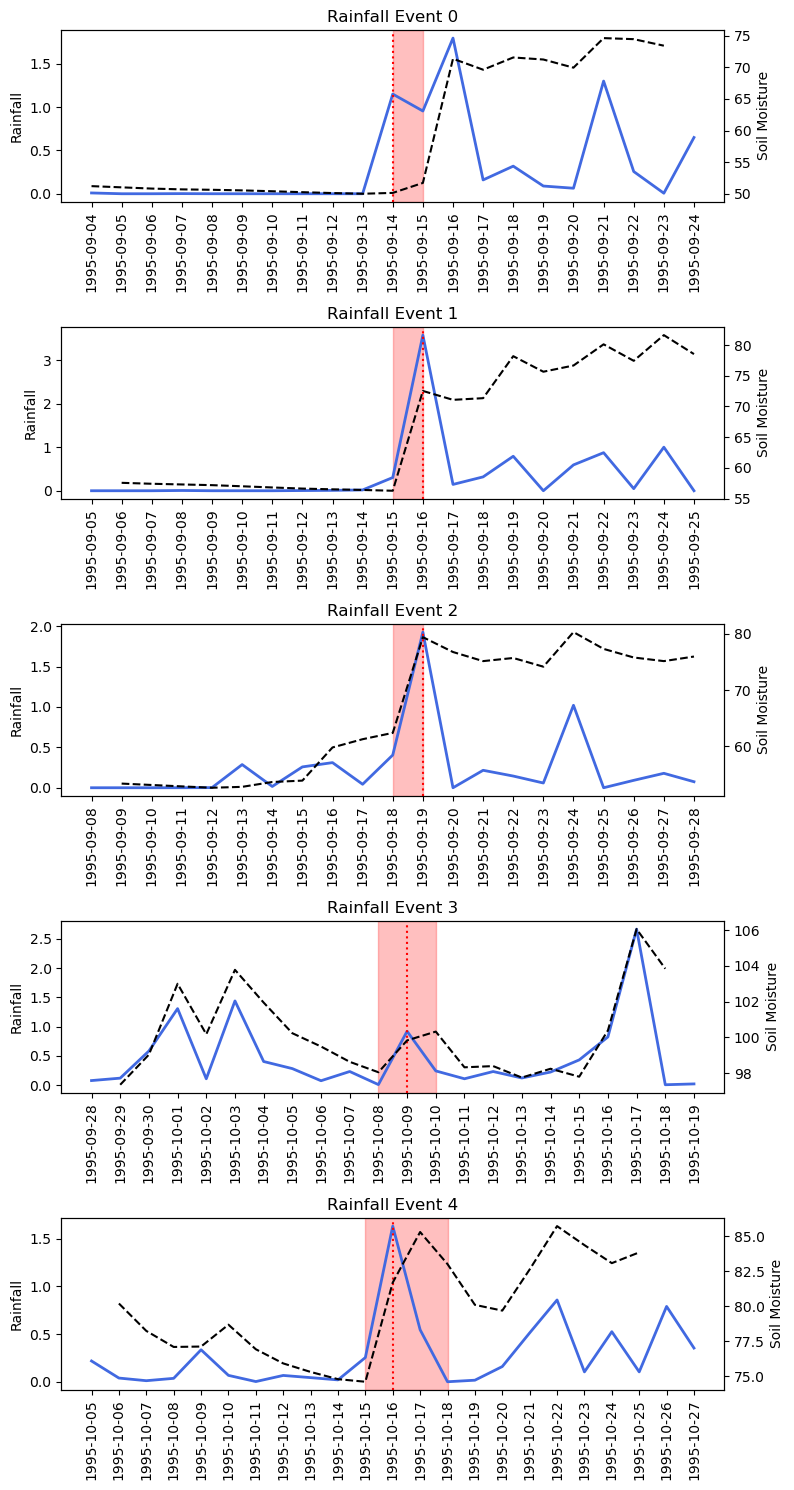

In [29]:
event_list = range(0, len(rainfall_events_oneyr))  # event indices you want to plot
n_events = len(event_list)

fig, axes = plt.subplots(n_events, 1, figsize=(8, 3*n_events), sharex=False)

if n_events == 1:
    axes = [axes]   # ensures iterable
    
for ax1, event_idx in zip(axes, event_list):

    start_index = int(rainfall_events_oneyr.iloc[event_idx]['start_indices'])-1
    stop_index = int(rainfall_events_oneyr.iloc[event_idx]['stop_indices'])-1

    start_index -= correction_factor
    stop_index  -= correction_factor

    # Rainfall subset
    subset = cube_catchment[start_index:stop_index,:,:].data

    flat_index = np.nanargmax(subset)
    t_local, y_idx, x_idx = np.unravel_index(flat_index, subset.shape)

    max_precip = subset[t_local, y_idx, x_idx]
    t_global = t_local + start_index

    # Coordinates of peak
    x_coord = cube_uk_oneyr.coord('projection_x_coordinate').points[x_idx]
    y_coord = cube_uk_oneyr.coord('projection_y_coordinate').points[y_idx]

    # Soil moisture at peak cell
    sm_one_yr_at_max_cell = sm_one_yr[:, y_idx, x_idx]

    # --- Time conversions ---
    time_coord = cube_catchment.coord('time')
    t = time_coord.units.num2date(time_coord.points[t_global])

    rainfall_peak_day = cftime.Datetime360Day(t.year, t.month, t.day)

    rainfall_start_t = time_coord.units.num2date(time_coord.points[start_index])
    rainfall_start_day = cftime.Datetime360Day(rainfall_start_t.year, rainfall_start_t.month, rainfall_start_t.day)

    rainfall_stop_t = time_coord.units.num2date(time_coord.points[stop_index])
    rainfall_stop_day = cftime.Datetime360Day(rainfall_stop_t.year, rainfall_stop_t.month, rainfall_stop_t.day)

    # Soil moisture window
    delta = datetime.timedelta(days=10)
    start_time = rainfall_peak_day - delta
    end_time   = rainfall_peak_day + delta

    subset_sm = sm_one_yr_at_max_cell.extract(
        iris.Constraint(time=lambda t: start_time <= t.point <= end_time)
    )

    # --- Rainfall daily means ---
    rain_cell = cube_catchment[:, y_idx, x_idx]
    icc.add_day_of_year(rain_cell, 'time')

    rain_daily = rain_cell.aggregated_by(['year','day_of_year'], iris.analysis.MEAN)

    window_start = rainfall_start_day - delta
    window_end   = rainfall_stop_day + delta

    rain_window = rain_daily.extract(
        iris.Constraint(time=lambda t: window_start <= t.point <= window_end)
    )

    rain_times = rain_window.coord('time').units.num2date(
        rain_window.coord('time').points
    )

    rain_times_str = [t.strftime('%Y-%m-%d') for t in rain_times]
    rain_values = rain_window.data

    # ---- Plot rainfall ----
    mask = ~np.isnan(rain_values)

    ax1.plot(np.array(rain_times_str)[mask],
             rain_values[mask],
             linewidth=2,
             color='royalblue')

    peak_str  = rainfall_peak_day.strftime('%Y-%m-%d')
    start_str = rainfall_start_day.strftime('%Y-%m-%d')
    end_str   = rainfall_stop_day.strftime('%Y-%m-%d')

    ax1.axvline(peak_str, color='red', linestyle="dotted")
    ax1.axvspan(start_str, end_str, color="red", alpha=0.25)

    ax1.set_ylabel("Rainfall")

    # ---- Soil moisture axis ----
    ax2 = ax1.twinx()

    times = subset_sm.coord('time').units.num2date(
        subset_sm.coord('time').points
    )

    times_str = [t.strftime('%Y-%m-%d') for t in times]
    values = subset_sm.data

    ax2.plot(times_str, values, color='black', linestyle='dashed')

    ax2.set_ylabel("Soil Moisture")

    ax1.set_title(f"Rainfall Event {event_idx}")
    ax1.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### Get rainfall netCDF for relevant year

### Mask out cells not within Newcastle

In [30]:

# start_index = int(rainfall_events_oneyr.iloc[event_idx]['start_indices'])-1
# stop_index = int(rainfall_events_oneyr.iloc[event_idx]['stop_indices'])-1

# start_index = start_index - correction_factor
# stop_index = stop_index - correction_factor
# print(start_index, stop_index)

# # Get just the part of the timeseries where it was raining
# subset = cube_catchment[start_index:stop_index, :, :].data

# # Find index of maximum value
# # This first internally flattens the array (e.g., subset.flatten(), so flattened length = 18 × 140 × 120)
# # flat_undex is the nth item in that flattened array
# flat_index = np.nanargmax(subset)

# # Convert to (time, x, y) indices
# # np.unravel_index converts a flat index back into the multi-dimensional indices.
# # t_local is the timestep within the event
# t_local, y_idx, x_idx = np.unravel_index(flat_index, subset.shape)

# # Actual precipitation value
# max_precip = subset[t_local, y_idx, x_idx]

# # convert time index back to original cube index
# # t_global is the timestep of the maximum within the whole event
# t_global = t_local + start_index

# # Find coordinates of peak cell
# x_coord = cube_uk_oneyr.coord('projection_x_coordinate').points[x_idx]
# y_coord = cube_uk_oneyr.coord('projection_y_coordinate').points[y_idx]

# print("Max precipitation:", max_precip)
# print("Time index:", t_global)
# print("Grid cell indices (x,y):", x_idx, y_idx)
# print("Grid cell coordinates (easting, northing):", x_coord, y_coord)

# sm_one_yr_at_max_cell = sm_one_yr[:, y_idx, x_idx]

# time_coord = cube_catchment.coord('time')
# t = time_coord.units.num2date(time_coord.points[t_global])
# rainfall_peak_day = cftime.Datetime360Day(t.year, t.month, t.day)

# rainfall_start_t = time_coord.units.num2date(time_coord.points[start_index])
# rainfall_start_day = cftime.Datetime360Day(rainfall_start_t.year, rainfall_start_t.month, rainfall_start_t.day)

# rainfall_stop_t = time_coord.units.num2date(time_coord.points[stop_index])
# rainfall_stop_day = cftime.Datetime360Day(rainfall_stop_t.year, rainfall_stop_t.month, rainfall_stop_t.day)

# delta = datetime.timedelta(days=10)

# start_time = rainfall_peak_day - delta
# end_time = rainfall_peak_day + delta

# subset = sm_one_yr_at_max_cell.extract(iris.Constraint(time=lambda t: start_time <= t.point <= end_time))

# # --- Rainfall at peak grid cell ---
# rain_cell = cube_catchment[:, y_idx, x_idx]

# # Add year/day_of_year coords for aggregation
# icc.add_day_of_year(rain_cell, 'time')

# # Aggregate to daily means
# rain_daily = rain_cell.aggregated_by(['year','day_of_year'], iris.analysis.MEAN)

# # Extract 10 days before and after event
# delta = datetime.timedelta(days=10)
# window_start = rainfall_start_day - delta
# window_end   = rainfall_stop_day + delta
# rain_window = rain_daily.extract(iris.Constraint(time=lambda t: window_start <= t.point <= window_end))
# rain_times = rain_window.coord('time').units.num2date(rain_window.coord('time').points)
# rain_times_str = [t.strftime('%Y-%m-%d') for t in rain_times]
# rain_values = rain_window.data

# fig,ax1=plt.subplots(figsize=(8,4))

# # Get formatted times
# peak_str = rainfall_peak_day.strftime('%Y-%m-%d')
# start_str = rainfall_start_day.strftime('%Y-%m-%d')
# end_str = rainfall_stop_day.strftime('%Y-%m-%d')

# # ------- Plot rainfall data (axis 1) -------
# mask = ~np.isnan(rain_values)
# ax1.plot(np.array(rain_times_str)[mask], rain_values[mask], linewidth=2, color='royalblue', label='Daily rainfall (peak cell)')
# ax1.set_ylabel("Daily rainfall") 

# # Plot time of peak, and start and stop of event
# ax1.axvline(peak_str, color='red', linestyle="dotted", label="Rainfall peak")
# ax1.axvspan(start_str, end_str, color="red", alpha=0.25, label="Rainfall event")

# ax1.tick_params(axis='x', rotation=90)

# # ------- Plot soil moisture data (axis 2) -------
# # Create secondary y-axis
# ax2 = ax1.twinx()

# # Get time values formatted for plotting
# time_coord = subset.coord('time')
# times = time_coord.units.num2date(time_coord.points)
# times_str = [t.strftime('%Y-%m-%d') for t in times]
# # Get 1D data array
# values = subset.data

# # Plot rainfall data
# ax2.plot(times_str, values, color='black', linestyle='dashed', label="Soil Moisture")

# ax2.set_ylabel("Soil Moisture")
# ax2.set_title("Soil Moisture around rainfall event")

# plt.legend()
# plt.tight_layout()
# plt.show()